In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# matplotlib.use('Agg')
import datetime

%matplotlib inline
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from stable_baselines3.common.logger import configure
from finrl.meta.data_processor import DataProcessor

from finrl.plot import backtest_stats, backtest_plot, get_daily_return, get_baseline
from pprint import pprint

import sys
sys.path.append("../FinRL")

import itertools

C:\Users\silve\anaconda3\envs\CM3070-FP\lib\site-packages\pyfolio\pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


warning above is not an issue since we are working with stocks, not futures so the multiplier is 1 by default.

In [2]:
from finrl import config
from finrl import config_tickers
import os
from finrl.main import check_and_make_directories
from finrl.config import (
    DATA_SAVE_DIR,
    TRAINED_MODEL_DIR,
    TENSORBOARD_LOG_DIR,
    RESULTS_DIR,
    INDICATORS,
    TRAIN_START_DATE,
    TRAIN_END_DATE,
    TEST_START_DATE,
    TEST_END_DATE,
    TRADE_START_DATE,
    TRADE_END_DATE,
)
check_and_make_directories([DATA_SAVE_DIR, TRAINED_MODEL_DIR, TENSORBOARD_LOG_DIR, RESULTS_DIR])

In [3]:
# from config.py, TRAIN_START_DATE is a string
TRAIN_START_DATE

'2014-01-06'

In [4]:
# from config.py, TRAIN_END_DATE is a string
TRAIN_END_DATE

'2020-07-31'

In [5]:
TODAY = datetime.datetime.today().strftime('%Y-%m-%d')

In [6]:
TRAIN_START_DATE = '2008-01-01'
TRAIN_END_DATE = '2023-01-01'
TRADE_START_DATE = '2023-01-01'
TRADE_END_DATE = TODAY

In [7]:
ticker_list = ['AAPL', 'AMGN', 'AMZN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'NVDA', 'PG', 'SWH', 'TRV', 'UNH', 'V', 'VZ', 'WMT']

In [8]:
df = YahooDownloader(start_date = TRAIN_START_DATE,
                     end_date = TRADE_END_DATE,
                     ticker_list = ticker_list).fetch_data()

YF deprecation warning: set proxy via new config function: yf.set_config(proxy=proxy)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Shape of DataFrame:  (131041, 8)


In [9]:
df

Price,date,close,high,low,open,volume,tic,day
0,2008-01-02,5.849121,6.011831,5.780376,5.982111,1079178800,AAPL,2
1,2008-01-02,31.964495,32.266307,31.731277,31.964495,7934400,AMGN,2
2,2008-01-02,4.812500,4.871500,4.735000,4.767500,277174000,AMZN,2
3,2008-01-02,38.800732,39.773790,38.610681,39.598944,8053700,AXP,2
4,2008-01-02,63.481609,64.375712,63.027225,64.177838,4303000,BA,2
...,...,...,...,...,...,...,...,...
131036,2025-08-22,276.290009,279.040009,275.760010,277.000000,1457600,TRV,4
131037,2025-08-22,307.420013,310.679993,304.579987,306.100006,14875600,UNH,4
131038,2025-08-22,350.040009,351.200012,345.220001,345.220001,4972300,V,4
131039,2025-08-22,44.439999,45.430000,44.250000,45.150002,19108700,VZ,4


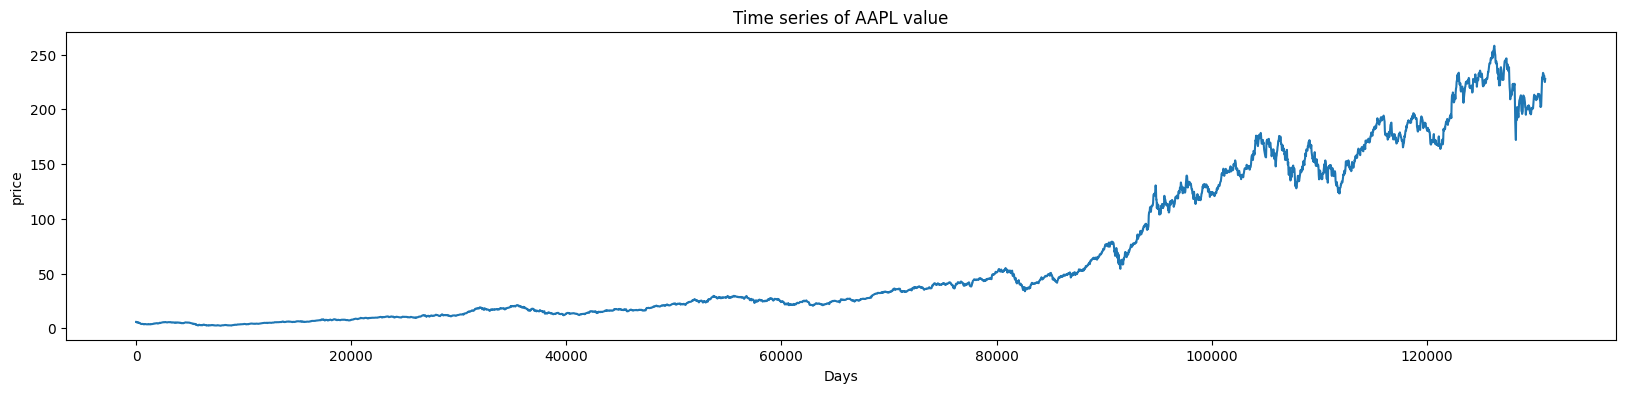

In [10]:
%matplotlib inline
# Create plot
fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(df[df['tic'] == 'AAPL']['close'])
plt.title("Time series of AAPL value")
plt.xlabel("Days")
plt.ylabel("price")
plt.show()

In [11]:
df.columns

Index(['date', 'close', 'high', 'low', 'open', 'volume', 'tic', 'day'], dtype='object', name='Price')

In [12]:
fe = FeatureEngineer(
                    use_technical_indicator=True,
                    tech_indicator_list = INDICATORS,
                    use_vix=True,
                    use_turbulence=True,
                    user_defined_feature = False)

processed = fe.preprocess_data(df)

Successfully added technical indicators


[*********************100%***********************]  1 of 1 completed


Shape of DataFrame:  (4438, 8)
Successfully added vix
Successfully added turbulence index


In [13]:
list_ticker = processed["tic"].unique().tolist()
list_date = list(pd.date_range(processed['date'].min(),processed['date'].max()).astype(str))
combination = list(itertools.product(list_date,list_ticker))

processed_full = pd.DataFrame(combination,columns=["date","tic"]).merge(processed,on=["date","tic"],how="left")
processed_full = processed_full[processed_full['date'].isin(processed['date'])]
processed_full = processed_full.sort_values(['date','tic'])

processed_full = processed_full.fillna(0)

In [14]:
processed_full.sort_values(['date','tic'],ignore_index=True).head(20)

,date,tic,close,high,low,open,volume,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,vix,turbulence
0,2008-01-02,AAPL,5.849121,6.011831,5.780376,5.982111,1.079179e+09,2.0,0.0,5.854289,5.846653,100.0,-66.666667,100.0,5.849121,5.849121,23.17,0.0
1,2008-01-02,AMGN,31.964495,32.266307,31.731277,31.964495,7.934400e+06,2.0,0.0,5.854289,5.846653,100.0,-66.666667,100.0,31.964495,31.964495,23.17,0.0
2,2008-01-02,AMZN,4.812500,4.871500,4.735000,4.767500,2.771740e+08,2.0,0.0,5.854289,5.846653,100.0,-66.666667,100.0,4.812500,4.812500,23.17,0.0
3,2008-01-02,AXP,38.800732,39.773790,38.610681,39.598944,8.053700e+06,2.0,0.0,5.854289,5.846653,100.0,-66.666667,100.0,38.800732,38.800732,23.17,0.0
4,2008-01-02,BA,63.481609,64.375712,63.027225,64.177838,4.303000e+06,2.0,0.0,5.854289,5.846653,100.0,-66.666667,100.0,63.481609,63.481609,23.17,0.0
5,2008-01-02,CAT,44.344864,45.625673,43.980716,45.556610,6.337800e+06,2.0,0.0,5.854289,5.846653,100.0,-66.666667,100.0,44.344864,44.344864,23.17,0.0
6,2008-01-02,CRM,14.939095,15.749494,14.837486,15.625580,4.980000e+06,2.0,0.0,5.854289,5.846653,100.0,-66.666667,100.0,14.939095,14.939095,23.17,0.0
7,2008-01-02,CSCO,17.368887,17.866262,17.152920,17.669930,6.433890e+07,2.0,0.0,5.854289,5.846653,100.0,-66.666667,100.0,17.368887,17.368887,23.17,0.0
8,2008-01-02,CVX,46.556919,47.169643,46.183308,46.805993,9.058000e+06,2.0,0.0,5.854289,5.846653,100.0,-66.666667,100.0,46.556919,46.556919,23.17,0.0
9,2008-01-02,DIS,26.569569,27.228802,26.444398,26.970115,9.269900e+06,2.0,0.0,5.854289,5.846653,100.0,-66.666667,100.0,26.569569,26.569569,23.17,0.0


In [15]:
processed_full.columns

Index(['date', 'tic', 'close', 'high', 'low', 'open', 'volume', 'day', 'macd',
       'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma',
       'close_60_sma', 'vix', 'turbulence'],
      dtype='object')

In [16]:
INDICATORS

['macd',
 'boll_ub',
 'boll_lb',
 'rsi_30',
 'cci_30',
 'dx_30',
 'close_30_sma',
 'close_60_sma']

In [17]:
import reservoirpy as rpy
from reservoirpy.nodes import Reservoir, Ridge
from reservoirpy.observables import mse, nrmse, rmse
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import time

In [18]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    mse_score = mse(y_true, y_pred)
    rmse_score = rmse_val  # Change the variable name here
    nmrse_mean = nrmse(y_true, y_pred, norm_value=y_true.mean())
    nmrse_maxmin = nrmse(y_true, y_pred, norm_value=y_true.max() - y_true.min())
    r2 = r2_score(y_true, y_pred)
    return mae, rmse_score, mape, mse_score, rmse_score, nmrse_mean, nmrse_maxmin, r2

In [19]:
def filter_data(dataframe, ticker):
    return dataframe[dataframe['tic'] == ticker]

In [20]:
def scale_data(dataframe):
    numeric_cols = dataframe.select_dtypes(include='number').columns
    scaler = MinMaxScaler(feature_range=(0, 1))
    df_scaled = dataframe.copy()
    df_scaled[numeric_cols] = scaler.fit_transform(dataframe[numeric_cols])
    return df_scaled[numeric_cols], scaler

In [21]:
dat, scaler = scale_data(filter_data(processed_full, 'AAPL'))

In [22]:
dat

,close,high,low,open,volume,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,vix,turbulence
0,0.013691,0.013829,0.013495,0.014119,0.315232,0.50,0.543586,0.011534,0.014900,1.000000,0.354835,1.000000,0.013174,0.013200,0.190755,0.000000
28,0.013702,0.013493,0.013512,0.013664,0.244447,0.75,0.543589,0.011534,0.014900,1.000000,0.354835,1.000000,0.013180,0.013205,0.181509,0.000000
56,0.011955,0.012980,0.011883,0.013198,0.427675,1.00,0.542879,0.012918,0.012122,0.002239,0.309132,1.000000,0.012569,0.012580,0.201224,0.000000
140,0.011672,0.011881,0.010861,0.011997,0.611678,0.00,0.542440,0.012737,0.011543,0.001406,0.312906,1.000000,0.012189,0.012191,0.199184,0.000000
168,0.010922,0.011748,0.010928,0.011866,0.447970,0.25,0.541834,0.012690,0.010805,0.000000,0.326720,1.000000,0.011804,0.011797,0.221482,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180180,0.896332,0.903007,0.892367,0.908681,0.009793,1.00,0.861790,0.897004,0.816188,0.628759,0.688688,0.462347,0.871533,0.864032,0.080897,0.115505
180264,0.893595,0.898488,0.895394,0.899657,0.004252,0.00,0.868957,0.903731,0.816635,0.622841,0.650053,0.462347,0.874438,0.866070,0.079538,0.024333
180292,0.892305,0.897514,0.892407,0.898010,0.004827,0.25,0.869514,0.909502,0.817188,0.619995,0.620504,0.428393,0.877289,0.868135,0.087424,0.034708
180320,0.874514,0.888166,0.878333,0.892909,0.005681,0.50,0.847630,0.912366,0.819133,0.582047,0.567060,0.278871,0.879361,0.870308,0.089055,0.024074


In [23]:
Dat = np.array(dat)

In [24]:
Dat

array([[0.01369097, 0.0138291 , 0.01349526, ..., 0.01319952, 0.19075458,
        0.        ],
       [0.01370152, 0.01349348, 0.01351177, ..., 0.0132052 , 0.18150916,
        0.        ],
       [0.01195494, 0.01298012, 0.01188314, ..., 0.0125801 , 0.20122365,
        0.        ],
       ...,
       [0.89230472, 0.89751438, 0.89240658, ..., 0.86813481, 0.08742351,
        0.03470793],
       [0.87451432, 0.88816564, 0.87833264, ..., 0.87030769, 0.08905505,
        0.02407444],
       [0.87017425, 0.87277913, 0.87050941, ..., 0.87205638, 0.1014276 ,
        0.03243767]])

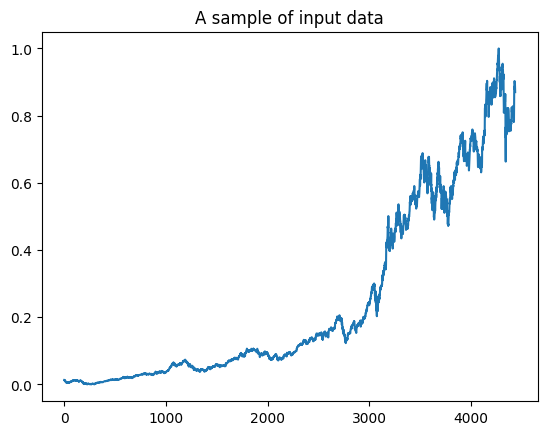

(4250, 16)
(4250, 1)
(100, 16)
(100, 1)


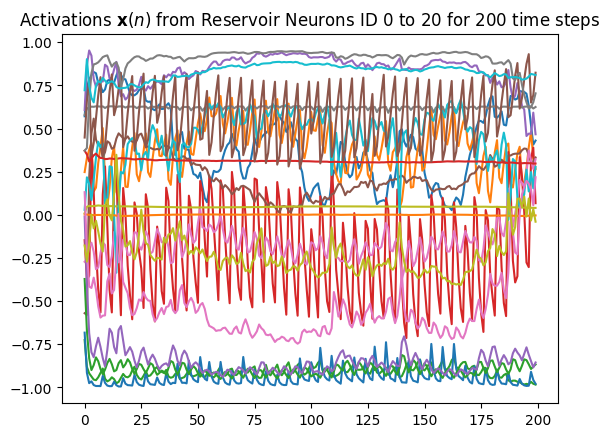

Mean Absolute Error (MAE): 0.0273
Root Mean Squared Error (RMSE): 0.0389
Mean Absolute Percentage Error (MAPE): 3.1644%
R-squared: 0.6594

********************
Errors computed over 100 time steps

Mean Squared error (MSE):	1.5122e-03
Root Mean Squared error (RMSE):	3.8888e-02
Normalized RMSE (based on mean):	4.3550e-02
Normalized RMSE (based on max - min):	1.1551e-01
********************


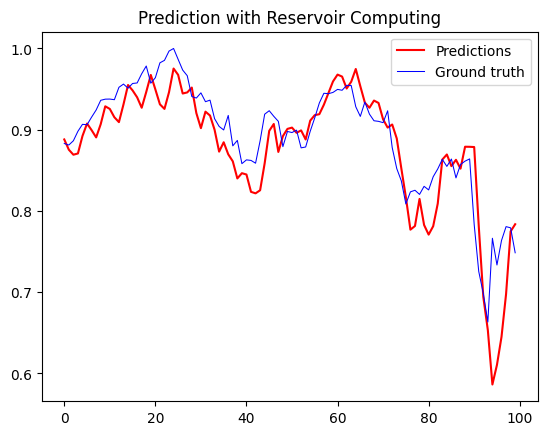

In [25]:
start_time = time.time()

# Load data from CSV
#df = pd.read_csv('your_dataset.csv')  # Replace 'your_dataset.csv' with your file name
dat, scaler = scale_data(filter_data(processed_full, 'AAPL'))
X = np.array(dat)
y = np.array(dat['close'])

# Set constants
SEED = 42
VERBOSE = False
units = 10000
horizon = 1

if __name__ == "__main__":
    rpy.set_seed(SEED)
    rpy.verbosity(0)

    if VERBOSE:
        print("Data dimensions", Dat.shape)
        print("max:", Dat.max(), "min:", Dat.min())
        print("mean:", Dat.mean(), "std:", Dat.std())

    plt.figure()
    plt.plot(y)
    plt.title("A sample of input data")
    plt.show()

    train_size = 4250
    test_size = 100

    X_train = X[:train_size]
    y_train = y[horizon : train_size + horizon].reshape(-1, 1)
    X_test = X[train_size : train_size + test_size]
    y_test = y[train_size + horizon : train_size + test_size + horizon].reshape(-1, 1)

    print(X_train.shape)
    print(y_train.shape)
    print(X_test.shape)
    print(y_test.shape)

    # Reservoir parameters
    units = 20
    leak_rate = 0.75
    rho = 1.025
    input_scaling = 1.0
    rc_connectivity = 0.15
    input_connectivity = 0.2
    fb_connectivity = 1.1
    regularization_coef = 1e-8
    warmup = 100
    feedback = False

    rng = np.random.default_rng(SEED)
    W = rng.random((units, units)) - 0.5
    input_bias = True  # Set to True or False depending on your choice
    Win = rng.random((units, 1 + int(input_bias))) - 0.5
    Wfb = rng.random((units, 1)) - 0.5

    mask = rng.random((units, units))
    W[mask > rc_connectivity] = 0

    mask = rng.random((units, Win.shape[1]))
    Win[mask > input_connectivity] = 0

    mask = rng.random((units, Wfb.shape[1]))
    Wfb[mask > fb_connectivity] = 0

    Win = Win * input_scaling

    # Calculate the spectral radius
    original_spectral_radius = np.max(np.abs(np.linalg.eigvals(W)))

    # Rescale the matrix to reach the requested spectral radius:
    W = W * (rho / original_spectral_radius)

    # Create a reservoir
    reservoir = Reservoir(
        units,
        lr=leak_rate,
        sr=rho,
        input_bias=input_bias,
        input_scaling=input_scaling,
        rc_connectivity=rc_connectivity,
        input_connectivity=input_connectivity,
        fb_connectivity=fb_connectivity,
    )

    readout = Ridge(ridge=regularization_coef)

    if feedback:
        reservoir = reservoir << readout

    esn = reservoir >> readout

    internal_trained = reservoir.run(X_train)

    reservoir.reset()

    plt.figure()
    plt.plot(internal_trained[:200, :21])
    plt.title("Activations $\\mathbf{x}(n)$ from Reservoir Neurons ID 0 to 20 for 200 time steps")
    plt.show()

    esn = esn.fit(X_train, y_train, warmup=warmup)

    y_pred = esn.run(X_test)

    mae, rmse, mape, mse_score, rmse_score, nmrse_mean, nmrse_maxmin, r2 = calculate_metrics(y_test, y_pred)

    print("Mean Absolute Error (MAE): {:.4f}".format(mae))
    print("Root Mean Squared Error (RMSE): {:.4f}".format(rmse))
    print("Mean Absolute Percentage Error (MAPE): {:.4f}%".format(mape))
    print("R-squared: {:.4f}".format(r2))
    print("\n********************")
    print(f"Errors computed over {test_size} time steps")
    print("\nMean Squared error (MSE):\t%.4e" % mse_score)
    print("Root Mean Squared error (RMSE):\t%.4e" % rmse_score)
    print("Normalized RMSE (based on mean):\t%.4e" % nmrse_mean)
    print("Normalized RMSE (based on max - min):\t%.4e" % nmrse_maxmin)
    print("********************")

    plt.figure()
    plt.plot(y_pred, color="red", lw=1.5, label="Predictions")
    plt.plot(y_test, color="blue", lw=0.75, label="Ground truth")
    plt.title("Prediction with Reservoir Computing")
    plt.legend()
    plt.show()

end_time = time.time()

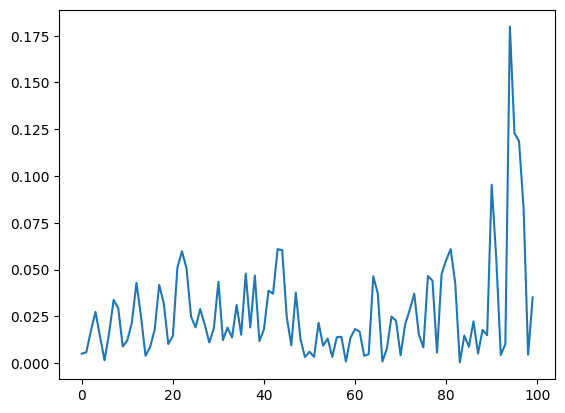

In [30]:
plt.plot(abs(y_test-y_pred).flatten(), linestyle='-', label="Prediction Error")
plt.show()